In [2]:
import pandas as pd
import os 
import jieba
import re
import numpy as np

In [3]:
file_name = 'similarity_record_2025邁向新世代前瞻人工智慧研究專案_合併版_推薦表統合_VBA_20250106.xlsx'
file_path = os.path.join(os.path.abspath("../data/output/"),file_name)
# 1. 最簡單的讀取方式
df = pd.read_excel(file_path)
data_dict = df.to_dict(orient='records')
analysis_datas = {}
for data in data_dict:
    if data['recommended_manager'] not in analysis_datas:
        analysis_datas[data['recommended_manager']] = [data]
    else:
        analysis_datas[data['recommended_manager']].append(data)
print(analysis_datas)

{'林耕民': [{'query_text': '可信賴的生成式虛擬三維組織病理學 組織病理學、生成式人工智慧、深度學習、生物醫學影像 三維虛擬組織病理學是醫學影像和診斷領域一項令人振奮的新興領域。它無需手術切片，透過高解析度灰階光學影像，生成類似傳統的組織病理學影像，以輔助醫師診斷。 鑑於本團隊在二維光學同調斷層掃描影像到H&E影像生成方面取得的國際領先成果，本計劃擬將其擴展到三維H&E 影像生成。此外，近年多種生物醫學影像技術在細胞解析度方面取得了快速發展，每種成像技術都能提取一些生物醫學特徵和特性，經由國際合作整合這些組織結構和成分之生物資訊，可以大幅推進生成的H&E 影像的可信任性。以臨床三維高解析度光學影像實現三維虛擬切片，可以使得個人化治療計劃中與放射組學、基因組學和數位孿生有更深層的結合。 本計畫擬分四年執行，第一年，除了二維細胞核及組織結構之外，將使用H&E 影像做半監督學習，增加色素性及功能性細胞之分割，我們也將實作一種參考引導降噪演算法來提升三維影像品質；第二年，將發展一種交叉引用的註釋方法，以精確分割三維細胞核邊界，並將採用標籤輔助的二維組織結構和成分轉換；第三年，將透過整合多樣化的生物醫學影像來實現三維生成式H&E 影像，並結合主動學習方法，以減少註釋需求；第四年，我們將嘗試解釋並分析模型推論結果，實現可信賴的三維虛擬組織病理學。', 'compared_text': '人工智慧在醫學影像及疾病預後之研究 大數據平台日漸發展，在產學研界的努力下，人工智慧崛起，帶動產業型態的改變。人工智慧技術逐步成熟，在所應用領域有相當突破性的發展。人工智慧在醫療上的應用主要提供客觀的診斷標準和減少醫療支出，提供高效率、精確且穩定的協助工具。    本計畫第一年擬研究基於影像前處理之機器學習預測糖尿病視網膜病變，針對糖尿病視網膜病變的影像進行二維卷積神經網路模型(CNN)之預測，主要著重在影像前處理的方法學，使用U-Net以及Entropy Image來增加影像特徵的顯著性，藉此提高診斷的精確度。本計畫第二年擬研究以生理與心理數據分析預測體適能表現，以花東地區職業軍人的生理與心理數據，比較傳統的統計方法-邏輯回歸分析和機器學習的模型-貝葉斯分類器、決策樹、隨機森林，以及深度學習的一維卷積神經網路模型來預估三種體適能成績-2分鐘的仰臥起坐、2分鐘的伏地挺身與30

In [4]:
recommand_count = {}
for data in analysis_datas.keys():
    recommand_count[data] = len(analysis_datas[data])
print(recommand_count)

{'林耕民': 15, '邱維辰': 22, '郭景明': 14, '葉瑞峰': 2, '莊永裕': 3, '朱彥煒': 14, '王毓淇': 14, '陳怡文': 1, '朱威達': 3, '陳敦裕': 1, '朱正忠': 8, '邱謙松': 7, '黃有評': 14, '陳宜欣': 3, '王振興': 21, '郭斯彥': 26, '傅立成': 17, '古倫維': 29, '吳宗憲': 13, '顏志達': 10, '陳縕儂': 14, '許煜亮': 17, '李濬屹': 11, '黃漢邦': 4, '詹魁元': 10, '林智揚': 22, '王凡': 16, '謝君偉': 11, '楊得年': 2, '李靜沛': 1, '陳弘軒': 1, '邱志義': 1, '高孟駿': 1, '陳以錚': 1, '林威成': 1, '林智仁': 1, '陳文村': 2, '周志遠': 2, '涂嘉恒': 5, '黃正民': 5, '黃國勝': 4, '李祖聖': 2, '黃敬群': 8, '郭秉寰': 2, '白敦文': 5, '蔡進聰': 5, '余松年': 8, '鄭文皇': 6, '黃慶育': 1, '黃瀚萱': 4, '簡仁宗': 5, '鄒耀東': 7, '曾新穆': 2, '洪樂文': 4, '林志哲': 2, '張玉山': 5, '陳俊達': 1, '傅楸善': 1, '阮雪芬': 1, '童俊維': 1, '郭至恩': 3, '吳謂勝': 1, '郭耀煌': 1, '黃駿賢': 2, '宋朝宗': 1, '陳定宏': 1, '張雲南': 5, '林彥宇': 5, '徐讚昇': 1, '薛幼苓': 4, '陳國益': 3, '黃士嘉': 5, '曹昱': 5, '梁詩婷': 1, '林柏廷': 2, '郭重顯': 5, '蕭得聖': 2, '王榮爵': 3, '張文中': 2, '林顯易': 2, '劉冠顯': 1, '李昌駿': 2, '鄭仙志': 1, '周至宏': 1, '蔡明義': 1, '陳增益': 2, '陳冠宇': 3, '李宏毅': 3, '李琳山': 4, '洪志偉': 3, '卓信宏': 2, '林盈達': 1, '雷伯瑞': 2, '陳志成': 1, '許健平': 2, '詹益東': 4, '練光祐': 2, '林祝興': 3, '朱

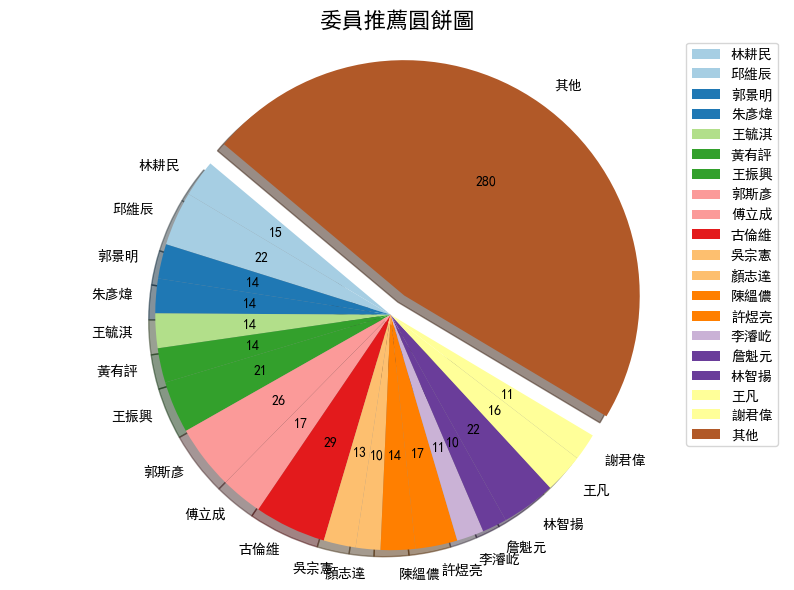

In [5]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np

# 使用更通用的字體設置
mpl.rcParams['font.family'] = 'sans-serif'
mpl.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'SimHei', 'DejaVu Sans', 'Bitstream Vera Sans', 'sans-serif']
mpl.rcParams['axes.unicode_minus'] = False

# 合併小類別
threshold = 10
other_sum = 0
new_recommand_count = {}

for label, size in recommand_count.items():
    if size < threshold:
        other_sum += size
    else:
        new_recommand_count[label] = size

if other_sum > 0:
    new_recommand_count['其他'] = other_sum

# 提取新的標籤和數值
labels = list(new_recommand_count.keys())
sizes = list(new_recommand_count.values())
colors = plt.cm.Paired(np.arange(len(new_recommand_count)) / len(new_recommand_count))

explode = [0] * len(new_recommand_count)
max_index = sizes.index(max(sizes))
explode[max_index] = 0.1

# 自定義函數，只顯示數值
def autopct_format(values):
    def my_format(pct):
        total = sum(values)
        val = int(round(pct*total/100.0))
        return '{:d}'.format(val)
    return my_format

plt.figure(figsize=(10, 7))
plt.pie(sizes, explode=explode, labels=labels, colors=colors,
        autopct=autopct_format(sizes), shadow=True, startangle=140)
plt.axis('equal')

plt.title('委員推薦圓餅圖', fontsize=16)
plt.legend(labels, loc="best")

plt.show()


In [6]:
common_words = []
def analyze_similarity(text1, text2):
    words1 = set(jieba.cut(text1))
    words2 = set(jieba.cut(text2))
    
    common = words1.intersection(words2)
    diff1 = words1 - words2
    diff2 = words2 - words1
    
    # print(f"共同關鍵詞: {common}")
    # print(f"Query 獨有詞: {diff1}")
    # print(f"結果 獨有詞: {diff2}")
    common_words.append(list(common))

for data in data_dict:
    analyze_similarity(data['query_text'],data['compared_text'])
print(common_words)

Building prefix dict from the default dictionary ...
Loading model from cache C:\Users\angel\AppData\Local\Temp\jieba.cache
Loading model cost 0.508 seconds.
Prefix dict has been built successfully.


[['學', '多種', '第二年', '來', '領域', '深度', '診斷', '第三年', '學習', '的', '。', '影像', '本計畫', '有', ' ', '可以', '於', '發展', '增加', '第一年', '品質', '和', '技術', '，', '以', '分割', '、', '使用', '第四年', '方法', '醫學', '與', '人工智慧', '傳統', '及', '之', '提升', '在', '精確'], ['學', '來', '領域', '深度', '成果', '學習', '將', '生成', '的', '。', '影像', '我們', '有', ' ', '於', '近年', '發展', '和', '技術', '，', '演算法', '資訊', '、', '使用', '中', '方法', '之外', '與', '人工智慧', '到', '之', '也', '在'], ['取得', '都', '擴展', '來', '領域', '深度', '組學', '能', '透過', '診斷', '學習', '將', '的', '監督學習', '。', '醫師', '影像', '本計畫', '有', ' ', '數位', '實現', '於', '結合', '轉換', '發展', '品質', '技術', '，', '了', '以', '演算法', '資訊', '、', '使用', '中', '方法', '醫學', '輔助', '在', '病理', '與', '人工智慧', '整合', '特性', '需求', '傳統', '及', '此外', '其', '到', '之', '註', '組織', '放射', '臨床', '也', '一種', '以輔助'], ['第二年', '來', '深度', '除了', '學習', '第三年', '生成', '的', '。', '影像', '本計畫', '我們', '有', ' ', '可以', '實現', '於', '發展', '增加', '第一年', '；', '結構', '技術', '，', '並將', '了', '以', '、', '資訊', '中', '方法', '執行', '與', '需求', '及', '此外', '其', '到', '之', '註', '提升', '也', '在'], 

In [7]:
flat_common_words = [word for sublist in common_words for word in sublist]
cleaned_words = [w for w in flat_common_words if re.match(r'^\w+$', w) and len(w)>1]
print(cleaned_words)

['多種', '第二年', '領域', '深度', '診斷', '第三年', '學習', '影像', '本計畫', '可以', '發展', '增加', '第一年', '品質', '技術', '分割', '使用', '第四年', '方法', '醫學', '人工智慧', '傳統', '提升', '精確', '領域', '深度', '成果', '學習', '生成', '影像', '我們', '近年', '發展', '技術', '演算法', '資訊', '使用', '方法', '之外', '人工智慧', '取得', '擴展', '領域', '深度', '組學', '透過', '診斷', '學習', '監督學習', '醫師', '影像', '本計畫', '數位', '實現', '結合', '轉換', '發展', '品質', '技術', '演算法', '資訊', '使用', '方法', '醫學', '輔助', '病理', '人工智慧', '整合', '特性', '需求', '傳統', '此外', '組織', '放射', '臨床', '一種', '以輔助', '第二年', '深度', '除了', '學習', '第三年', '生成', '影像', '本計畫', '我們', '可以', '實現', '發展', '增加', '第一年', '結構', '技術', '並將', '資訊', '方法', '執行', '需求', '此外', '提升', '領域', '深度', '學習', '生成', '影像', '本計畫', '數位', '可以', '實現', '解析度', '結合', '近年', '發展', '增加', '技術', '並將', '分割', '參考', '虛擬', '使用', '方法', '特性', '需求', '傳統', '大幅', '此外', '提升', '合作', '一種', '取得', '第二年', '深度', '透過', '學習', '第三年', '生成', '結果', '我們', '第一年', '結構', '使用', '方法', '輔助', '人工智慧', '特性', '提升', '合作', '臨床', '第二年', '領域', '深度', '透過', '診斷', '第三年', '學習', '醫師', '影像', '本計畫', '可以', '增加', '第一年', '

In [8]:
from collections import Counter

# 統計出現次數
word_counts = Counter(cleaned_words)
# 顯示前 10 名最相關的關鍵詞
for word, count in word_counts.most_common():
    print(f"{word}: {count} 次")


技術: 422 次
應用: 410 次
系統: 404 次
學習: 335 次
模型: 329 次
本計畫: 328 次
研究: 306 次
發展: 288 次
整合: 277 次
智慧: 276 次
計畫: 251 次
開發: 200 次
資料: 194 次
深度: 191 次
透過: 188 次
人工智慧: 187 次
AI: 187 次
進行: 184 次
提升: 168 次
提供: 153 次
架構: 144 次
平台: 142 次
分析: 139 次
醫療: 134 次
能力: 127 次
領域: 118 次
目標: 115 次
以及: 114 次
設計: 110 次
環境: 106 次
建立: 106 次
使用: 99 次
影像: 92 次
核心: 91 次
建構: 89 次
臨床: 88 次
訓練: 88 次
實現: 87 次
結合: 87 次
我們: 85 次
問題: 85 次
提出: 84 次
機器: 83 次
演算法: 70 次
方法: 68 次
生成: 68 次
台灣: 68 次
本計: 68 次
感知: 67 次
控制: 66 次
診斷: 65 次
同時: 64 次
基礎: 63 次
預測: 61 次
解決: 60 次
語言: 59 次
研發: 58 次
合作: 56 次
創新: 55 次
安全: 54 次
理解: 53 次
視覺: 53 次
輔助: 52 次
互動: 52 次
偵測: 52 次
不同: 52 次
完成: 52 次
機制: 51 次
需求: 50 次
一套: 50 次
照護: 49 次
策略: 49 次
一個: 49 次
網路: 49 次
有效: 49 次
處理: 48 次
第二年: 47 次
資訊: 47 次
快速: 47 次
醫學: 46 次
具備: 46 次
具有: 46 次
自主: 45 次
強化: 45 次
場域: 45 次
子計畫: 45 次
裝置: 44 次
評估: 44 次
運算: 43 次
第三年: 40 次
第一年: 40 次
辨識: 40 次
因此: 40 次
包括: 39 次
效能: 39 次
健康: 38 次
包含: 38 次
神經: 37 次
關鍵: 37 次
實際: 37 次
功能: 37 次
決策: 36 次
然而: 36 次
目前: 36 次
利用: 34 次
語意: 34 次
產業: 34 

In [15]:
import pandas as pd
import os

file_name = 'AICOE\初審委員(5學門)整理 (僅篩選).xlsx'
file_path = os.path.join(os.path.abspath("../data/research_proj/"), file_name)

# 要保留的欄位
columns_to_keep = ['計畫中文名稱', '中文摘要', '中文關鍵詞']

# 讀取所有分頁
all_sheets = pd.read_excel(file_path, sheet_name=None)

# 用於存儲所有分頁的結果
all_data = []

# 處理每個分頁
for sheet_name, df in all_sheets.items():
    print(f"處理分頁: {sheet_name}")
    
    # 檢查分頁是否包含所需的欄位
    missing_columns = [col for col in columns_to_keep if col not in df.columns]
    if missing_columns:
        print(f"  警告: 分頁 '{sheet_name}' 缺少以下欄位: {missing_columns}")
        print(f"  可用的欄位: {df.columns.tolist()}")
        continue
    
    # 只保留需要的欄位
    df_filtered = df[columns_to_keep]
    
    # 轉換為字典列表
    data_dict = df_filtered.to_dict(orient='records')
    
    # 添加到總結果中
    all_data.extend(data_dict)
    
    print(f"  已處理 {len(data_dict)} 筆資料")

print(f"\n總共收集了 {len(all_data)} 筆資料")

處理分頁: 115
  已處理 849 筆資料

總共收集了 849 筆資料


In [17]:
print(all_data[0])
name = []
summary = []
keywords = []
for data in all_data:
    name.append(data['計畫中文名稱'])
    summary.append(data['中文摘要'])
    keywords.append(data['中文關鍵詞'])

{'計畫中文名稱': '基礎圖論與幾何問題的串流資料演算法', '中文摘要': '當資料量大過記憶體能夠容納的範圍時，傳統的演算法無法直接拿來使用，需要有不一樣的方法來處理資料，而串流式演算法主要是被設計來處理這一類的問題。在這個研究計畫中，我們主要會探討如何針對圖論和計算幾何的基礎問題來設計串流式演算法，因為這兩類基礎的問題在整個資訊領域有很廣泛的應用。', '中文關鍵詞': '串流式演算法；圖論；計算幾何；下界'}


In [18]:
import pandas as pd
import numpy as np
import jieba
import jieba.analyse
from collections import Counter
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# 創建DataFrame以方便分析
df = pd.DataFrame({
    '計畫中文名稱': name,
    '中文摘要': summary,
    '中文關鍵詞': keywords
})

# 顯示基本統計信息
print(f"總計畫數量: {len(df)}")
print(f"計畫名稱平均長度: {df['計畫中文名稱'].str.len().mean():.2f} 字元")
print(f"中文摘要平均長度: {df['中文摘要'].str.len().mean():.2f} 字元")
print(f"中文關鍵字平均長度: {df['中文關鍵詞'].str.len().mean():.2f} 字元")

# 分析常見詞彙（以摘要為例）
all_words = []
for text in df['中文摘要'].dropna():
    words = jieba.lcut(text)
    all_words.extend(words)

word_count = Counter(all_words)
print("\n摘要中最常見的20個詞:")
print(word_count.most_common(20))

總計畫數量: 849
計畫名稱平均長度: 27.54 字元
中文摘要平均長度: 463.51 字元
中文關鍵字平均長度: 37.03 字元

摘要中最常見的20個詞:
[('，', 11870), ('的', 11064), ('。', 5434), (' ', 3978), ('與', 3165), ('、', 2780), ('在', 2105), ('於', 2068), ('之', 2005), ('研究', 1517), (')', 1490), ('(', 1404), ('技術', 1270), ('為', 1141), ('系統', 1114), ('資料', 990), ('應用', 970), ('對', 951), ('學習', 943), ('是', 936)]


In [20]:
def load_stopwords():
    # 從檔案載入中文停用詞列表
    file_path = 'stopwords.txt'
    stopwords = set()
    try:
        with open(file_path, 'r', encoding='utf-8') as file:
            for line in file:
                word = line.strip()
                if word:  # 確保不是空行
                    stopwords.add(word)
        print(f"成功從 {file_path} 載入了 {len(stopwords)} 個停用詞")
    except FileNotFoundError:
        print(f"找不到停用詞檔案: {file_path}")
        # 提供一些基本停用詞作為備用
        stopwords = set([
            '的', '是', '在', '和', '與', '了', '對', '等', '能', '都', '。', '，', '、',
            '及', '中', '為', '以', '將', '各', '其', '或', '並', '也', '於', '上', '而',
            '之', '這', '那', '有', '我們', '可以', '就是', '不', '也是', '這個', '通過'
        ])
        print(f"使用預設的 {len(stopwords)} 個停用詞")
    except UnicodeDecodeError:
        print(f"讀取檔案時發生編碼錯誤，請確保檔案使用 UTF-8 編碼")
        # 嘗試使用不同的編碼
        try:
            with open(file_path, 'r', encoding='big5') as file:
                for line in file:
                    word = line.strip()
                    if word:
                        stopwords.add(word)
            print(f"使用 BIG5 編碼成功載入了 {len(stopwords)} 個停用詞")
        except:
            # 提供基本停用詞作為備用
            stopwords = set([
                '的', '是', '在', '和', '與', '了', '對', '等', '能', '都', '。', '，', '、',
                '及', '中', '為', '以', '將', '各', '其', '或', '並', '也', '於', '上', '而'
            ])
            print(f"無法讀取檔案，使用預設的 {len(stopwords)} 個停用詞")
    
    return stopwords

stopwords = load_stopwords()

成功從 stopwords.txt 載入了 1203 個停用詞


In [21]:
# 使用停用詞處理文本
def process_text(text, stopwords):
    if pd.isna(text):
        return ""
    words = jieba.lcut(text)
    filtered_words = [word for word in words if word not in stopwords and len(word) > 1]
    return " ".join(filtered_words)

# 處理摘要
df['處理後摘要'] = df['中文摘要'].apply(lambda x: process_text(x, stopwords))

# 分析處理後的常見詞彙
processed_words = []
for text in df['處理後摘要'].dropna():
    words = text.split()
    processed_words.extend(words)

processed_word_count = Counter(processed_words)
print("\n去除停用詞後摘要中最常見的20個詞:")
print(processed_word_count.most_common(20))



去除停用詞後摘要中最常見的20個詞:
[('研究', 1517), ('技術', 1270), ('系統', 1114), ('資料', 990), ('應用', 970), ('學習', 943), ('網路', 893), ('本計畫', 848), ('分析', 778), ('進行', 699), ('設計', 687), ('模型', 626), ('計畫', 619), ('發展', 619), ('問題', 567), ('開發', 553), ('方法', 551), ('深度', 522), ('機器', 510), ('影像', 489)]


In [22]:
import pandas as pd
import numpy as np
import re
import jieba
from collections import Counter

# 處理關鍵字 - 先分割不同的關鍵字
def process_keywords(keyword_list):
    all_keywords = []
    
    for keyword in keyword_list:
        # 檢查是否為 NaN 或 None
        if keyword is None or pd.isna(keyword):
            continue
        
        # 轉換為字符串並移除前後空格
        keyword_str = str(keyword).strip()
        
        # 跳過 'nan' 字符串和空字符串
        if keyword_str.lower() == 'nan' or not keyword_str:
            continue
            
        # 統一分隔符號並分割
        normalized = re.sub(r'[、，,;；\s]+', '|', keyword_str)
        split_keywords = normalized.split('|')
        
        # 處理每個分割後的關鍵字
        for k in split_keywords:
            k = k.strip()
            if k and len(k) >= 2:
                all_keywords.append(k)
    
    return all_keywords

# 處理關鍵字 - 得到單獨的關鍵字列表
all_keyword = process_keywords(keywords)

print(f"處理後的關鍵字列表 (共 {len(all_keyword)} 個):")
print(all_keyword[:20])  # 只顯示前20個

# 使用 jieba 對每個關鍵字進行斷詞
segmented_keywords = []
for keyword in all_keyword:
    # 使用jieba進行斷詞
    seg_list = jieba.cut(keyword)
    # 將斷詞結果轉為列表並添加到結果中
    seg_words = list(seg_list)
    segmented_keywords.append(seg_words)

# 顯示斷詞結果
# print("\n使用 jieba 斷詞後的關鍵字 (前20個):")
# for i, (orig, seg) in enumerate(zip(all_keyword[:20], segmented_keywords[:20])):
#     print(f"{i+1}. 原始: {orig} -> 斷詞: {' / '.join(seg)}")

# 將所有斷詞結果展平為一個列表
all_terms = []
for seg_list in segmented_keywords:
    all_terms.extend(seg_list)

# 過濾掉長度為1的詞
filtered_terms = [term for term in all_terms if len(term) > 1]

# 計算詞頻
term_counts = Counter(filtered_terms)

# 顯示最常見的詞
print("\n最常見的20個詞 (長度>1):")
for term, count in term_counts.most_common():
    print(f"{term}: {count}")


處理後的關鍵字列表 (共 5191 個):
['串流式演算法', '圖論', '計算幾何', '下界', '控制學門', '規劃', '推動', '審核', '智慧計算學門', '專題計畫', '研究成果', '科技部', '機械固力學門', '研究發展及推動', '學門網頁製作維護', '專題及重大研發成果發表會', '深層學習', '類神經網路', '機器學習', '生成式對抗網路']

最常見的20個詞 (長度>1):
學習: 378
網路: 270
深度: 213
系統: 164
機器: 144
分析: 124
資料: 100
模型: 84
影像: 82
記憶體: 82
人工智慧: 78
智慧: 70
偵測: 69
計算: 64
神經: 63
辨識: 58
生成: 56
軟體: 55
運算: 53
演算法: 51
安全: 50
控制: 47
設計: 47
行動: 46
處理: 45
技術: 45
通訊: 45
實境: 44
邊緣: 44
語音: 42
材料: 42
語言: 40
物聯網: 39
基因: 38
虛擬: 37
資訊: 36
結構: 34
預測: 34
最佳化: 32
對抗: 29
電腦: 29
檢測: 28
定位: 28
管理: 28
程式: 28
視覺: 27
隱私: 27
壓縮: 27
儲存: 27
無線: 27
自動: 27
非揮: 27
發性: 27
雲端: 26
強化: 25
自然: 25
整合: 25
感知: 25
動態: 25
醫療: 24
有限: 24
物件: 22
架構: 22
探勘: 22
類神經: 21
異質: 21
服務: 21
元素: 21
輔助: 21
生物: 21
人機: 20
效能: 20
平台: 20
優化: 20
可靠: 20
數位: 19
定義網: 19
3D: 19
視訊: 19
感測: 19
資源: 18
互動: 18
介面: 18
監督式: 18
裝置: 18
特徵: 18
三維: 18
奈米: 18
混合: 18
模糊: 18
搜尋: 17
知識: 17
攻擊: 17
轉換: 17
編碼: 17
時間: 17
問題: 16
擴增: 16
車聯網: 16
推薦: 16
切片: 16
智能: 16
卷積: 16
精準: 16
存取: 16
規劃: 15
機械: 15
分散式: 15
量子: 15
應用: 